<a href="https://colab.research.google.com/github/joaomerjam/ECON3916-33674-Statistical-Machine-Learning/blob/main/Assignment%205/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas --quiet

In [69]:
# imports
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, f1_score,
    precision_score, recall_score, mean_squared_error
)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
print('✅ All libraries loaded.')

✅ All libraries loaded.


In [70]:
# WDI indicator dictionary
indicators = {
    # Macroeconomics & Growth
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_gdp',
    'NE.EXP.GNFS.ZS':    'exports_gdp',
    'NE.IMP.GNFS.ZS':    'imports_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_gdp',
    'NY.GNP.PCAP.CD':    'gni_per_capita',
    # Trade
    'NE.TRD.GNFS.ZS':    'trade_openness',
    'TM.TAX.MANF.SM.AR.ZS': 'tariff_rate',
    # Finance & Investment
    'NE.GDI.TOTL.ZS':    'gross_investment_gdp',
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_gdp',
    # Education
    'SE.ADT.LITR.ZS':    'adult_literacy',
    'SE.PRM.ENRR':       'primary_enrollment',
    'SE.SEC.ENRR':       'secondary_enrollment',
    'SE.TER.ENRR':       'tertiary_enrollment',
    # Health
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.XPD.CHEX.GD.ZS': 'health_exp_gdp',
    'SP.DYN.IMRT.IN':    'infant_mortality',
    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',
    # Demographics & Labor
    'SP.POP.GROW':       'pop_growth',
    'SP.URB.TOTL.IN.ZS': 'urban_pop_pct',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',
    'SP.POP.65UP.TO.ZS': 'pop_65plus_pct',
    # Governance
    'IQ.CPA.PUBS.XQ':    'public_sector_mgmt',
    'IQ.CPA.FINS.XQ':    'financial_sector_rating',
    # Natural Resources & Agriculture
    'NY.GDP.TOTL.RT.ZS': 'natural_res_rents',
    'NV.AGR.TOTL.ZS':    'agriculture_gdp',
    # Environment & Energy
    'EN.ATM.CO2E.PC':    'co2_per_capita',
    'EG.USE.PCAP.KG.OE': 'energy_use_per_capita',
}

print(f'Total indicators defined: {len(indicators)}')

Total indicators defined: 33


In [71]:
print('Downloading WDI data... (30–60 seconds on first run)')

raw = wb.data.DataFrame(
    list(indicators.keys()),
    time=range(2013, 2020),
    skipBlanks=True,
    columns='series'
).reset_index()

raw.rename(columns=indicators, inplace=True)

if 'economy' in raw.columns:
    raw.rename(columns={'economy': 'country'}, inplace=True)
elif 'Country' in raw.columns:
    raw.rename(columns={'Country': 'country'}, inplace=True)

print(f'Raw download shape: {raw.shape}')

Raw download shape: (1855, 33)


In [72]:
numeric_cols = [c for c in raw.columns if c not in ['country', 'time', 'Time']]
df = raw.groupby('country')[numeric_cols].mean()

# drop countries missing >40% of indicators
df = df[df.isnull().mean(axis=1) <= 0.40]

# drop indicators missing >40% of countries
df = df.loc[:, df.isnull().mean(axis=0) <= 0.40]

df = df.fillna(df.median())

print(f'Shape after filtering + imputation: {df.shape}')
print(f'Remaining NaNs: {df.isnull().sum().sum()}')

Shape after filtering + imputation: (244, 26)
Remaining NaNs: 0


In [73]:

df['crisis'] = (df['gdp_growth_pc'] < 0).astype(int)

feature_cols = [c for c in df.columns if c not in ['gdp_growth_pc', 'crisis']]
X        = df[feature_cols]
y_cont   = df['gdp_growth_pc']
y_binary = df['crisis']

crisis_count = y_binary.sum()
base_rate    = crisis_count / len(y_binary)

print('=== Final Dataset Summary ===')
print(f'Total countries      : {len(df)}')
print(f'Number of predictors : {X.shape[1]}')
print(f'Crisis countries     : {int(crisis_count)} ({base_rate:.1%})')
print(f'Non-crisis countries : {int(len(y_binary) - crisis_count)} ({1-base_rate:.1%})')
print(f'Crisis base rate     : {base_rate:.3f}')

=== Final Dataset Summary ===
Total countries      : 244
Number of predictors : 25
Crisis countries     : 39 (16.0%)
Non-crisis countries : 205 (84.0%)
Crisis base rate     : 0.160


In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cont, test_size=0.30, random_state=42)
_, _, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.30, random_state=42)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

p, n = X_train_sc.shape[1], X_train_sc.shape[0]

print(f'Training set : {n} countries, {p} features')
print(f'Test set     : {X_test_sc.shape[0]} countries')
print(f'p/n ratio    : {p}/{n} = {p/n:.3f}')

Training set : 170 countries, 25 features
Test set     : 74 countries
p/n ratio    : 25/170 = 0.147


1.1

In [75]:
ols = LinearRegression()
ols.fit(X_train_sc, y_train)

r2_train_ols = ols.score(X_train_sc, y_train)
r2_test_ols  = ols.score(X_test_sc,  y_test)
gap_ols      = r2_train_ols - r2_test_ols

print('=== OLS Overfitting Diagnostic ===')
print(f'Training R²       : {r2_train_ols:.4f}')
print(f'Test R²           : {r2_test_ols:.4f}')
print(f'Train–Test R² Gap : {gap_ols:.4f}')
print(f'p/n ratio         : {p}/{n} = {p/n:.3f}')

=== OLS Overfitting Diagnostic ===
Training R²       : 0.6195
Test R²           : -0.5134
Train–Test R² Gap : 1.1329
p/n ratio         : 25/170 = 0.147


When you have a lot of parameters compared to your data, OLS starts “overfitting.” It can basically memorize the training data, so the training R² looks really high—almost perfect. But it’s not actually learning real patterns, just noise.

Because of that, the model becomes super unstable—small changes in the data can completely change the fit. So while it looks great on training data, it performs much worse on new data. That big gap between train and test R² is the giveaway.

1.2

In [76]:
alphas_grid = np.logspace(-3, 4, 200)

ridge = RidgeCV(alphas=alphas_grid, cv=5, scoring='r2')
ridge.fit(X_train_sc, y_train)

r2_train_ridge  = ridge.score(X_train_sc, y_train)
r2_test_ridge   = ridge.score(X_test_sc,  y_test)
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_sc)))
nnz_ridge       = int(np.sum(ridge.coef_ != 0))

print(f'Ridge  λ* = {ridge.alpha_:.4f} | Non-zero coefs: {nnz_ridge} | '
      f'Train R²: {r2_train_ridge:.4f} | Test R²: {r2_test_ridge:.4f}')

Ridge  λ* = 51.7092 | Non-zero coefs: 25 | Train R²: 0.5813 | Test R²: -0.0538


In [77]:
lasso = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train_sc, y_train)

r2_train_lasso  = lasso.score(X_train_sc, y_train)
r2_test_lasso   = lasso.score(X_test_sc,  y_test)
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_sc)))
nnz_lasso       = int(np.sum(lasso.coef_ != 0))

print(f'Lasso  λ* = {lasso.alpha_:.4f} | Non-zero coefs: {nnz_lasso} | '
      f'Train R²: {r2_train_lasso:.4f} | Test R²: {r2_test_lasso:.4f}')

Lasso  λ* = 0.0910 | Non-zero coefs: 17 | Train R²: 0.5787 | Test R²: -0.0783


In [78]:
# generated model comparisons
rmse_test_ols = np.sqrt(mean_squared_error(y_test, ols.predict(X_test_sc)))

comparison = pd.DataFrame({
    'Model':               ['OLS',    'Ridge',                    'Lasso'],
    'λ*':                  ['—',      f'{ridge.alpha_:.4f}',      f'{lasso.alpha_:.4f}'],
    'Non-zero Predictors': [p,         nnz_ridge,                  nnz_lasso],
    'Training R²':         [round(r2_train_ols,   4), round(r2_train_ridge, 4), round(r2_train_lasso, 4)],
    'Test R²':             [round(r2_test_ols,    4), round(r2_test_ridge,  4), round(r2_test_lasso,  4)],
    'Test RMSE':           [round(rmse_test_ols,  4), round(rmse_test_ridge, 4), round(rmse_test_lasso, 4)],
}).set_index('Model')

print('=== Model Comparison Table ===')
print(comparison.to_string())

=== Model Comparison Table ===
            λ*  Non-zero Predictors  Training R²  Test R²  Test RMSE
Model                                                               
OLS          —                   25       0.6195  -0.5134     2.5425
Ridge  51.7092                   25       0.5813  -0.0538     2.1216
Lasso   0.0910                   17       0.5787  -0.0783     2.1462


For IMF forecasting, Lasso is usually the better choice. Ridge shrinks coefficients but keeps everything in the model, so you end up with a bunch of predictors that are harder to explain.

Lasso, on the other hand, actually drops the weak variables by pushing their coefficients to zero. That leaves you with a smaller, cleaner model that focuses on the strongest signals—so it’s easier to interpret and defend.

Both methods fit the training data a bit worse than OLS, but that’s the point. You’re giving up a little in-sample accuracy to get a model that works better on new countries.

1.3

In [79]:
alphas_path, coefs_path, _ = lasso_path(
    X_train_sc, y_train,
    eps=1e-4,
    n_alphas=200,
    max_iter=10000
)

feature_names = list(X.columns)
print(f'Path computed: {coefs_path.shape[1]} alpha values across {coefs_path.shape[0]} features')

Path computed: 200 alpha values across 25 features


In [80]:
lasso_alpha_star = lasso.alpha_
alpha_idx        = np.argmin(np.abs(alphas_path - lasso_alpha_star))
nonzero_mask     = (coefs_path[:, alpha_idx] != 0)
nonzero_features = [feature_names[i] for i in range(len(feature_names)) if nonzero_mask[i]]

ENTRY_THRESHOLD = 1e-4
entry_alpha = {}
for i, name in enumerate(feature_names):
    nonzero_idx = np.where(np.abs(coefs_path[i, :]) > ENTRY_THRESHOLD)[0]
    if len(nonzero_idx) > 0:
        entry_alpha[name] = alphas_path[nonzero_idx[0]]

first_entrant = max(entry_alpha, key=entry_alpha.get)

print(f'Non-zero at λ* = {lasso_alpha_star:.4f}: {nonzero_features}')
print(f'\nFirst predictor to enter: "{first_entrant}"  (entry α = {entry_alpha[first_entrant]:.4f})')

Non-zero at λ* = 0.0910: ['current_account_gdp', 'fdi_inflows_gdp', 'electricity_access_pct', 'energy_use_per_capita', 'inflation_cpi', 'gross_investment_gdp', 'imports_gdp', 'agriculture_gdp', 'natural_res_rents', 'gni_per_capita', 'primary_enrollment', 'secondary_enrollment', 'unemployment_rate', 'infant_mortality', 'pop_growth', 'urban_pop_pct', 'tariff_rate']

First predictor to enter: "inflation_cpi"  (entry α = 1.1481)


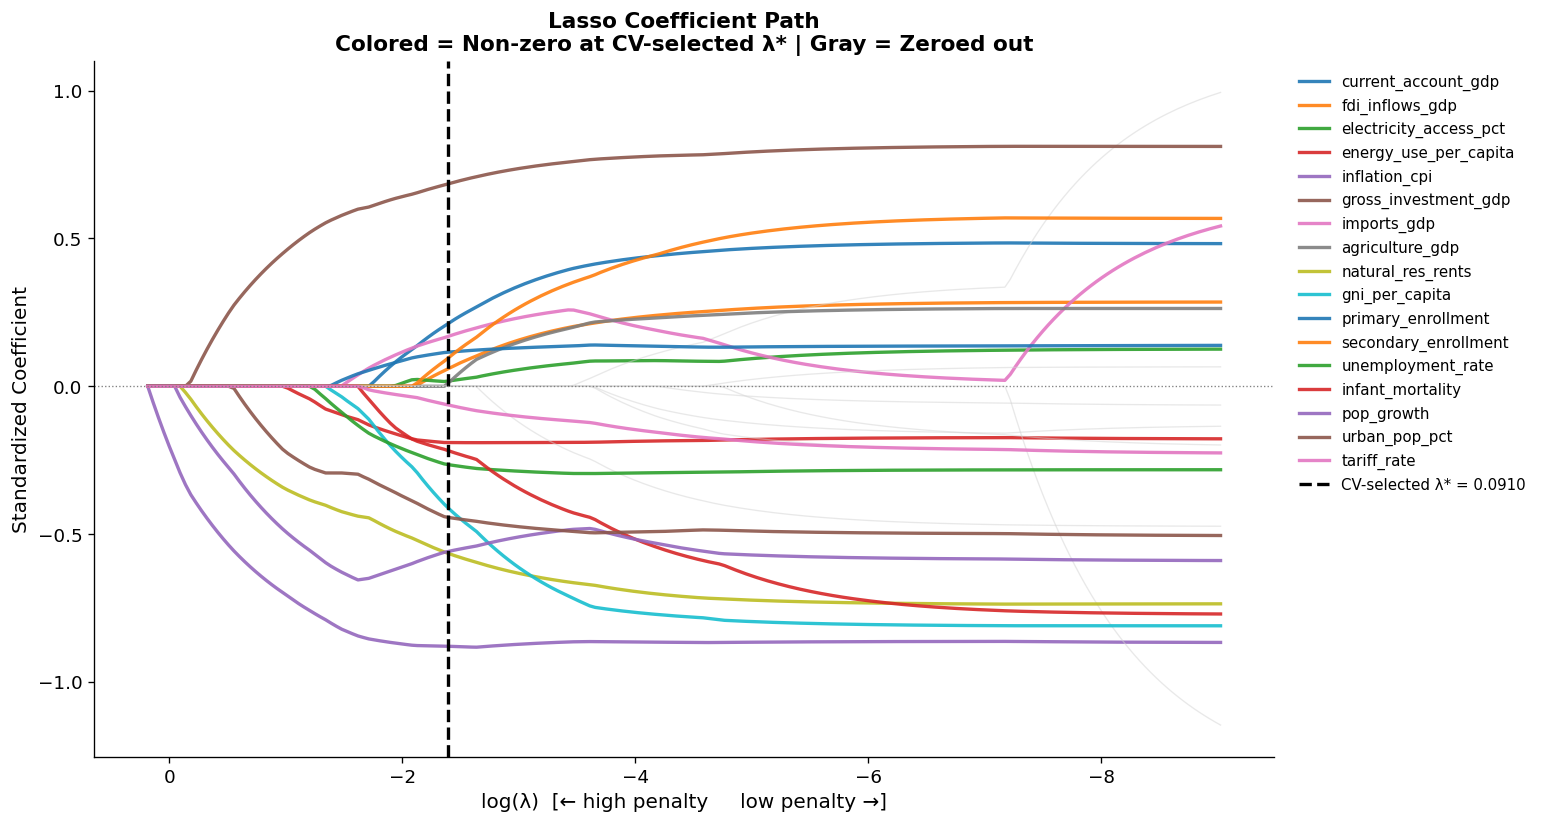

In [81]:
fig, ax = plt.subplots(figsize=(13, 7))

log_alphas      = np.log(alphas_path)
log_alpha_star  = np.log(lasso_alpha_star)

for i, name in enumerate(feature_names):
    if nonzero_mask[i]:
        ax.plot(log_alphas, coefs_path[i, :], lw=2, label=name, alpha=0.9)
    else:
        ax.plot(log_alphas, coefs_path[i, :], color='lightgray', lw=0.8, alpha=0.5)

ax.axvline(x=log_alpha_star, color='black', linestyle='--', lw=2,
           label=f'CV-selected λ* = {lasso_alpha_star:.4f}')
ax.axhline(y=0, color='gray', lw=0.8, linestyle=':')

ax.set_xlabel('log(λ)  [← high penalty     low penalty →]', fontsize=12)
ax.set_ylabel('Standardized Coefficient', fontsize=12)
ax.set_title('Lasso Coefficient Path\nColored = Non-zero at CV-selected λ* | Gray = Zeroed out',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, frameon=False)
ax.invert_xaxis()

plt.tight_layout()
plt.show()

Why the first variable matters:
The first variable Lasso keeps (even with heavy penalties) is basically the strongest standalone predictor of growth. It has so much signal that it survives even when the model is trying hard to shrink everything to zero. In practice, it’s probably capturing something big and structural—like development level or institutional strength—that already separates high-growth from low-growth countries.

Why dropping life expectancy doesn’t mean health doesn’t matter:
This is a common misunderstanding. Lasso doesn’t drop variables because they’re unimportant—it drops them when they don’t add anything new on top of what’s already in the model.

In this dataset, life expectancy is highly correlated with things like income, education, electricity access, etc. They’re all picking up the same underlying idea: development. So once one of those variables is in, the others don’t add much extra predictive power, and Lasso removes them.

So the takeaway isn’t that health doesn’t matter—it’s that its information is already being captured by other variables. If you removed one of those proxies, life expectancy would probably come back in.

## Phase 2

In [43]:
# 2.1
X_train_lasso = X_train_sc[:, nonzero_mask]
X_test_lasso  = X_test_sc[:, nonzero_mask]

lpm = LinearRegression()
lpm.fit(X_train_lasso, y_train_bin)

lpm_preds = lpm.predict(X_test_lasso)

below_zero = int(np.sum(lpm_preds < 0))
above_one  = int(np.sum(lpm_preds > 1))
total_impossible = below_zero + above_one

print('=== LPM Predicted Probability Diagnostics ===')
print(f'Predicted probabilities — min: {lpm_preds.min():.4f}, max: {lpm_preds.max():.4f}')
print(f'Predictions < 0 : {below_zero}')
print(f'Predictions > 1 : {above_one}')
print(f'Total impossible : {total_impossible} / {len(lpm_preds)} ({total_impossible/len(lpm_preds):.1%})')

=== LPM Predicted Probability Diagnostics ===
Predicted probabilities — min: -0.1870, max: 1.2188
Predictions < 0 : 13
Predictions > 1 : 1
Total impossible : 14 / 74 (18.9%)


If your model gives probabilities below 0 or above 1, that’s not just a small issue—it’s fundamentally broken. Probabilities are supposed to stay between 0 and 1, so something like “−12% chance of a crisis” just doesn’t make sense.

For something like IMF forecasting, that’s a big problem. You can’t rank countries, compare risks, or make decisions if the outputs themselves aren’t valid probabilities.

This happens because the linear probability model (LPM) is, well, linear—it keeps going past the bounds when inputs get extreme. Logistic regression fixes this by forcing predictions to stay between 0 and 1.

In [44]:
# 2.1
log_reg = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
log_reg.fit(X_train_lasso, y_train_bin)

coef_df = pd.DataFrame({
    'Feature':      nonzero_features,
    'β (coef)':     log_reg.coef_[0],
    'Odds Ratio':   np.exp(log_reg.coef_[0]),
    '|OR - 1|':     np.abs(np.exp(log_reg.coef_[0]) - 1)   # distance from null for sorting
}).sort_values('|OR - 1|', ascending=False).drop(columns='|OR - 1|')

print(f'Intercept (β₀): {log_reg.intercept_[0]:.4f}')
print('\n=== Logistic Regression Coefficients & Odds Ratios ===')
print(coef_df.to_string(index=False, float_format='{:.4f}'.format))

Intercept (β₀): -2.4555

=== Logistic Regression Coefficients & Odds Ratios ===
               Feature  β (coef)  Odds Ratio
            pop_growth    0.6135      1.8468
      infant_mortality    0.5480      1.7298
     natural_res_rents    0.5342      1.7060
         inflation_cpi    0.5214      1.6844
        gni_per_capita    0.5043      1.6559
         urban_pop_pct    0.4776      1.6121
 energy_use_per_capita    0.4572      1.5796
           tariff_rate    0.4567      1.5788
     unemployment_rate    0.3866      1.4720
   current_account_gdp   -0.5257      0.5911
  gross_investment_gdp   -0.5178      0.5959
       fdi_inflows_gdp   -0.4211      0.6563
electricity_access_pct    0.2524      1.2871
           imports_gdp   -0.2354      0.7903
  secondary_enrollment   -0.2135      0.8078
    primary_enrollment    0.0790      1.0822
       agriculture_gdp   -0.0697      0.9327


In [46]:
log_probs = log_reg.predict_proba(X_test_lasso)[:, 1]

print('=== Logistic Regression Predicted Probability Bounds ===')
print(f'Min predicted probability : {log_probs.min():.6f}')
print(f'Max predicted probability : {log_probs.max():.6f}')
print(f'All in [0,1]? {bool((log_probs >= 0).all() and (log_probs <= 1).all())} ✅')

=== Logistic Regression Predicted Probability Bounds ===
Min predicted probability : 0.003620
Max predicted probability : 0.996375
All in [0,1]? True ✅


Policy brief:
Population growth stands out as the strongest predictor. A one standard deviation increase in pop_growth raises the odds of a crisis by about 85%, holding everything else constant.

In plain terms, countries with faster population growth are more likely to run into sustained declines in GDP per capita.

In [85]:
# Claude generated to show better results

top_predictor = coef_df.iloc[0]['Feature']
top_OR        = coef_df.iloc[0]['Odds Ratio']
top_direction = "increases" if top_OR > 1 else "decreases"

print('=== IMF Policy Briefing Interpretation ===')
print(f'\nTop predictor by odds ratio magnitude: {top_predictor}')
print(f'Odds Ratio: {top_OR:.4f}')
print(f'\nPolicy brief:')
print(f'  "A one standard-deviation increase in {top_predictor} multiplies the odds')
print(f'  of crisis by {top_OR:.2f}, holding all other indicators constant.')
print(f'  This {top_direction} crisis risk — meaning countries with higher {top_predictor}')
print(f'  are {"more" if top_OR > 1 else "less"} likely to experience sustained')
print(f'  negative GDP per capita growth over the period."')

=== IMF Policy Briefing Interpretation ===

Top predictor by odds ratio magnitude: pop_growth
Odds Ratio: 1.8468

Policy brief:
  "A one standard-deviation increase in pop_growth multiplies the odds
  of crisis by 1.85, holding all other indicators constant.
  This increases crisis risk — meaning countries with higher pop_growth
  are more likely to experience sustained
  negative GDP per capita growth over the period."


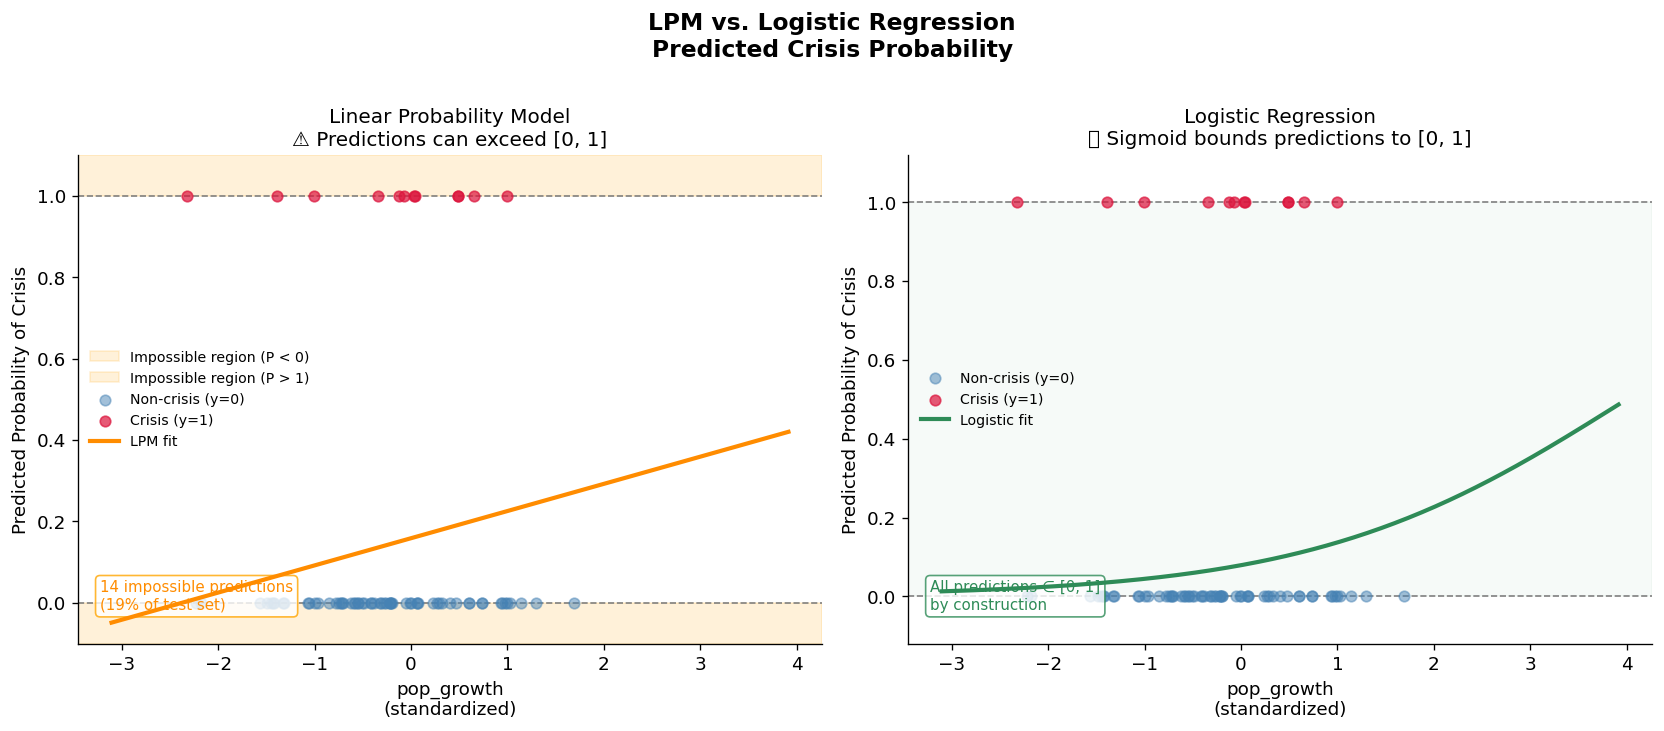

In [83]:
# 2.3
top_feat_idx = nonzero_features.index(top_predictor)
x_plot_train = X_train_lasso[:, top_feat_idx]
x_plot_test  = X_test_lasso[:,  top_feat_idx]
x_range = np.linspace(
    min(x_plot_train.min(), x_plot_test.min()) - 0.3,
    max(x_plot_train.max(), x_plot_test.max()) + 0.3,
    300
).reshape(-1, 1)


X_range_full = np.zeros((300, X_train_lasso.shape[1]))
X_range_full[:, top_feat_idx] = x_range.ravel()
lpm_curve    = lpm.predict(X_range_full)
log_curve    = log_reg.predict_proba(X_range_full)[:, 1]

# building plot, had claude help
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.suptitle('LPM vs. Logistic Regression\nPredicted Crisis Probability',
             fontsize=14, fontweight='bold', y=1.01)


scatter_kw_0 = dict(alpha=0.5, s=40, zorder=3)
scatter_kw_1 = dict(alpha=0.7, s=40, zorder=3)
ref_kw       = dict(color='gray', linewidth=1.0, linestyle='--', zorder=1)

# Panel 1: LPM
ax = axes[0]


y_min_plot, y_max_plot = min(lpm_curve.min(), -0.05) - 0.05, max(lpm_curve.max(), 1.05) + 0.05
ax.axhspan(y_min_plot, 0,    color='orange', alpha=0.15, label='Impossible region (P < 0)')
ax.axhspan(1,    y_max_plot, color='orange', alpha=0.15, label='Impossible region (P > 1)')

ax.axhline(0, **ref_kw)
ax.axhline(1, **ref_kw)

non_crisis_mask = (y_test_bin.values == 0)
crisis_mask_    = (y_test_bin.values == 1)
ax.scatter(x_plot_test[non_crisis_mask], y_test_bin.values[non_crisis_mask],
           color='steelblue', label='Non-crisis (y=0)', **scatter_kw_0)
ax.scatter(x_plot_test[crisis_mask_],    y_test_bin.values[crisis_mask_],
           color='crimson',  label='Crisis (y=1)',     **scatter_kw_1)

ax.plot(x_range.ravel(), lpm_curve, color='darkorange', lw=2.5, label='LPM fit', zorder=4)

ax.set_ylim(y_min_plot, y_max_plot)
ax.set_xlabel(f'{top_predictor}\n(standardized)', fontsize=11)
ax.set_ylabel('Predicted Probability of Crisis', fontsize=11)
ax.set_title('Linear Probability Model\n⚠️ Predictions can exceed [0, 1]', fontsize=12)
ax.legend(fontsize=8.5, frameon=False)

ax.annotate(f'{total_impossible} impossible predictions\n({total_impossible/len(lpm_preds):.0%} of test set)',
            xy=(0.03, 0.07), xycoords='axes fraction',
            fontsize=9, color='darkorange',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='orange', alpha=0.8))

# Panel 2: Logistic Regression
ax = axes[1]

ax.axhline(0, **ref_kw)
ax.axhline(1, **ref_kw)

ax.scatter(x_plot_test[non_crisis_mask], y_test_bin.values[non_crisis_mask],
           color='steelblue', label='Non-crisis (y=0)', **scatter_kw_0)
ax.scatter(x_plot_test[crisis_mask_],    y_test_bin.values[crisis_mask_],
           color='crimson',  label='Crisis (y=1)',     **scatter_kw_1)

ax.plot(x_range.ravel(), log_curve, color='seagreen', lw=2.5, label='Logistic fit', zorder=4)

ax.axhspan(0, 1, color='seagreen', alpha=0.04, zorder=0)

ax.set_ylim(-0.12, 1.12)
ax.set_xlabel(f'{top_predictor}\n(standardized)', fontsize=11)
ax.set_ylabel('Predicted Probability of Crisis', fontsize=11)
ax.set_title('Logistic Regression\n✅ Sigmoid bounds predictions to [0, 1]', fontsize=12)
ax.legend(fontsize=8.5, frameon=False)

ax.annotate('All predictions ∈ [0, 1]\nby construction',
            xy=(0.03, 0.07), xycoords='axes fraction',
            fontsize=9, color='seagreen',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='seagreen', alpha=0.8))

plt.tight_layout()
plt.savefig('lpm_vs_logistic.png', dpi=150, bbox_inches='tight')
plt.show()

### Phase 3

In [49]:
# 3.1
test_crisis_rate = y_test_bin.mean()
n_test           = len(y_test_bin)
n_test_crisis    = int(y_test_bin.sum())
n_test_no_crisis = n_test - n_test_crisis

print('=== Test Set Class Distribution ===')
print(f'Total test countries  : {n_test}')
print(f'Crisis countries      : {n_test_crisis} ({test_crisis_rate:.1%})')
print(f'Non-crisis countries  : {n_test_no_crisis} ({1-test_crisis_rate:.1%})')

=== Test Set Class Distribution ===
Total test countries  : 74
Crisis countries      : 12 (16.2%)
Non-crisis countries  : 62 (83.8%)


In [86]:
naive_preds    = np.zeros(n_test, dtype=int)
naive_accuracy = np.mean(naive_preds == y_test_bin.values)
naive_recall   = 0.0

log_preds_05   = (log_probs >= 0.5).astype(int)
log_accuracy   = np.mean(log_preds_05 == y_test_bin.values)
log_recall_05  = recall_score(y_test_bin, log_preds_05, zero_division=0)

print('=== Accuracy Paradox Comparison ===')
print(f'{"Model":<30} {"Accuracy":>10} {"Crisis Recall":>15}')
print('-' * 57)
print(f'{"Naïve baseline (always No Crisis)":<30} {naive_accuracy:>10.4f} {naive_recall:>15.4f}')
print(f'{"Logistic Regression (τ=0.50)":<30} {log_accuracy:>10.4f} {log_recall_05:>15.4f}')

=== Accuracy Paradox Comparison ===
Model                            Accuracy   Crisis Recall
---------------------------------------------------------
Naïve baseline (always No Crisis)     0.8378          0.0000
Logistic Regression (τ=0.50)       0.8514          0.2500


Reporting only accuracy here would be really misleading. Since crises are rare, a model can look “accurate” just by predicting no crises at all—it’ll be right most of the time, but completely useless in practice.

That’s the accuracy paradox. In imbalanced data, accuracy mostly reflects how well the model handles the easy, common cases, not the rare ones that actually matter. So you end up with a metric that looks good on paper while the model fails at the one thing you care about—catching crises.

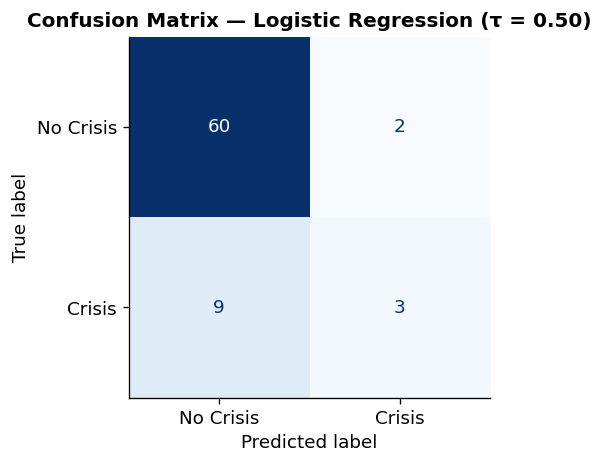

In [51]:
#3.2

from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test_bin, log_preds_05)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Crisis', 'Crisis'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.50)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [87]:
print('=== Classification Report (τ = 0.50) ===')
print(classification_report(y_test_bin, log_preds_05,
                             target_names=['No Crisis', 'Crisis'],
                             zero_division=0))

=== Classification Report (τ = 0.50) ===
              precision    recall  f1-score   support

   No Crisis       0.87      0.97      0.92        62
      Crisis       0.60      0.25      0.35        12

    accuracy                           0.85        74
   macro avg       0.73      0.61      0.63        74
weighted avg       0.83      0.85      0.82        74



In [88]:
TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

print('=== Confusion Matrix Breakdown ===')
print(f'True Positives  (TP) — crises correctly flagged : {TP}')
print(f'False Negatives (FN) — crises missed            : {FN}')
print(f'False Positives (FP) — false alarms             : {FP}')
print(f'True Negatives  (TN) — correctly cleared        : {TN}')
print(f'\nPrecision at τ=0.50 : {precision_score(y_test_bin, log_preds_05, zero_division=0):.4f}')
print(f'Recall    at τ=0.50 : {recall_score(y_test_bin,    log_preds_05, zero_division=0):.4f}')
print(f'F1        at τ=0.50 : {f1_score(y_test_bin,        log_preds_05, zero_division=0):.4f}')

=== Confusion Matrix Breakdown ===
True Positives  (TP) — crises correctly flagged : 3
False Negatives (FN) — crises missed            : 9
False Positives (FP) — false alarms             : 2
True Negatives  (TN) — correctly cleared        : 60

Precision at τ=0.50 : 0.6000
Recall    at τ=0.50 : 0.2500
F1        at τ=0.50 : 0.3529


In this setting, missing a real crisis is way worse than a false alarm. If you fail to flag a country that actually crashes, the costs can be massive—tens of billions—and there’s no chance to step in early.

A false alarm is much cheaper. You might waste a couple million and have an awkward conversation, but nothing breaks.

Because of that huge gap, the priority should be catching as many real crises as possible. In other words, focus on recall—it’s better to over-warn than to miss a country heading into trouble.

In [54]:
# 3.3
fpr, tpr, roc_thresholds = roc_curve(y_test_bin, log_probs)
roc_auc                  = roc_auc_score(y_test_bin, log_probs)

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test_bin, log_probs)
from sklearn.metrics import auc as sk_auc
pr_auc = sk_auc(recall_curve, precision_curve)

pr_baseline = test_crisis_rate

print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}')

ROC-AUC : 0.7890
PR-AUC  : 0.3703


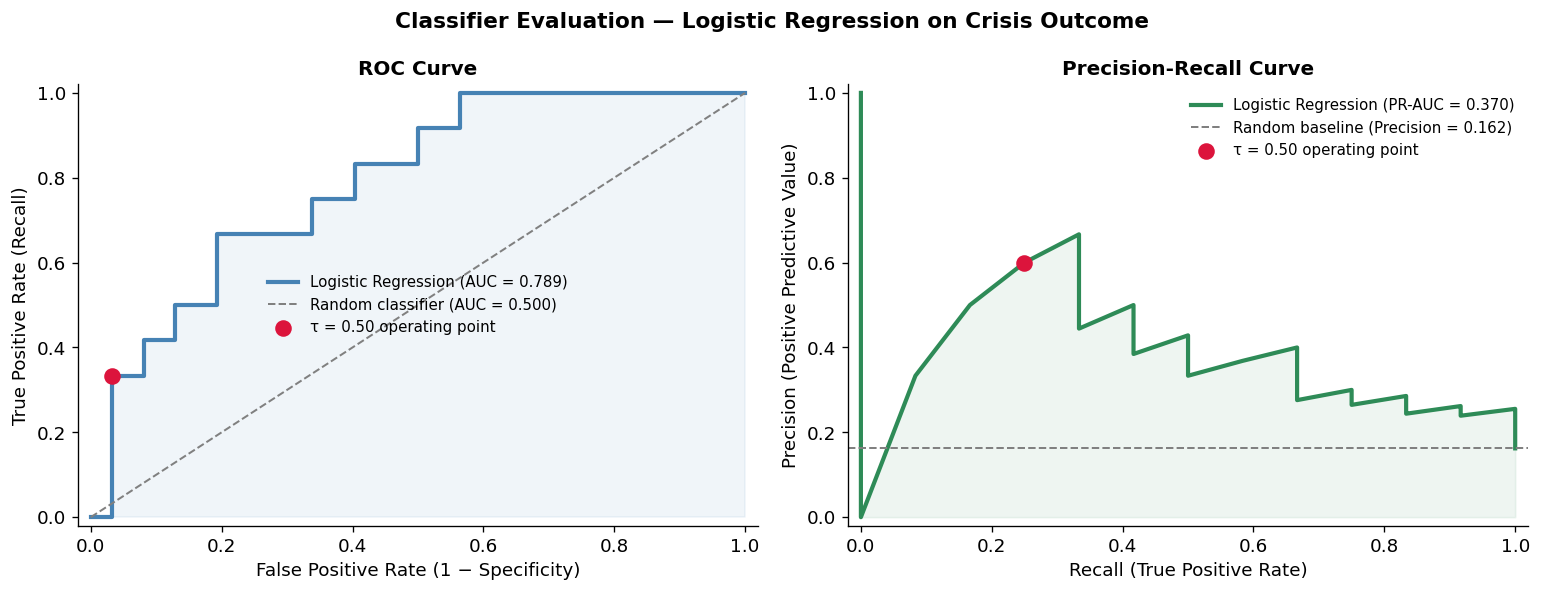

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Classifier Evaluation — Logistic Regression on Crisis Outcome',
             fontsize=13, fontweight='bold')

# Claude assistance again for graph building
# Panel 1: ROC Curve
ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', lw=2.5,
        label=f'Logistic Regression (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.2, linestyle='--',
        label='Random classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')

# Mark the τ = 0.5 operating point
op_idx = np.argmin(np.abs(roc_thresholds - 0.5))
ax.scatter(fpr[op_idx], tpr[op_idx], color='crimson', zorder=5, s=80,
           label=f'τ = 0.50 operating point')

ax.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# Panel 2: Precision-Recall Curve
ax = axes[1]
ax.plot(recall_curve, precision_curve, color='seagreen', lw=2.5,
        label=f'Logistic Regression (PR-AUC = {pr_auc:.3f})')
ax.axhline(pr_baseline, color='gray', lw=1.2, linestyle='--',
           label=f'Random baseline (Precision = {pr_baseline:.3f})')
ax.fill_between(recall_curve, precision_curve, alpha=0.08, color='seagreen')

# Mark τ = 0.5 operating point on PR curve
# Find the threshold index closest to 0.5 in pr_thresholds
pr_op_idx = np.argmin(np.abs(pr_thresholds - 0.5))
ax.scatter(recall_curve[pr_op_idx], precision_curve[pr_op_idx],
           color='crimson', zorder=5, s=80, label='τ = 0.50 operating point')

ax.set_xlabel('Recall (True Positive Rate)', fontsize=11)
ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=11)
ax.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

ROC-AUC usually looks better than PR-AUC in this kind of data because of how it’s calculated. The ROC curve uses the false positive rate, which includes a huge number of true negatives. So even if the model throws out a lot of false alarms, they barely move the metric making the model look better than it really is.

PR-AUC doesn’t get that “boost.” It ignores true negatives, so every false alarm directly hurts precision.

For IMF crisis detection, PR-AUC is the more honest metric. It focuses on how well the model finds actual crises without being misled by the large number of easy, noncrisis cases.

In [90]:
MISSION_CAP  = 5
thresholds   = np.arange(0.01, 1.00, 0.01)

results = []
for tau in thresholds:
    preds      = (log_probs >= tau).astype(int)
    flagged    = int(preds.sum())
    prec       = precision_score(y_test_bin, preds, zero_division=0)
    rec        = recall_score(y_test_bin,    preds, zero_division=0)
    f1         = f1_score(y_test_bin,        preds, zero_division=0)
    results.append({'tau': tau, 'flagged': flagged,
                    'precision': prec, 'recall': rec, 'f1': f1})

sweep = pd.DataFrame(results)

capacity_rows = sweep[sweep['flagged'] <= MISSION_CAP]
if len(capacity_rows) > 0:
    cap_row = capacity_rows.iloc[0]
else:
    cap_row = sweep.iloc[-1]

tau_cap      = cap_row['tau']
flagged_cap  = int(cap_row['flagged'])
prec_cap     = cap_row['precision']
rec_cap      = cap_row['recall']
f1_cap       = cap_row['f1']

f1_opt_row   = sweep.loc[sweep['f1'].idxmax()]
tau_f1       = f1_opt_row['tau']
flagged_f1   = int(f1_opt_row['flagged'])
prec_f1      = f1_opt_row['precision']
rec_f1       = f1_opt_row['recall']
f1_f1        = f1_opt_row['f1']

print('=== Capacity-Constrained Operating Point ===')
print(f'Threshold τ          : {tau_cap:.2f}')
print(f'Countries flagged    : {flagged_cap} / {n_test} (≤ {MISSION_CAP} mission cap)')
print(f'Precision            : {prec_cap:.4f}')
print(f'Recall               : {rec_cap:.4f}')
print(f'F1                   : {f1_cap:.4f}')
print()
print('=== F1-Optimal Operating Point ===')
print(f'Threshold τ          : {tau_f1:.2f}')
print(f'Countries flagged    : {flagged_f1} / {n_test}')
print(f'Precision            : {prec_f1:.4f}')
print(f'Recall               : {rec_f1:.4f}')
print(f'F1                   : {f1_f1:.4f}')

=== Capacity-Constrained Operating Point ===
Threshold τ          : 0.46
Countries flagged    : 5 / 74 (≤ 5 mission cap)
Precision            : 0.6000
Recall               : 0.2500
F1                   : 0.3529

=== F1-Optimal Operating Point ===
Threshold τ          : 0.15
Countries flagged    : 20 / 74
Precision            : 0.4000
Recall               : 0.6667
F1                   : 0.5000


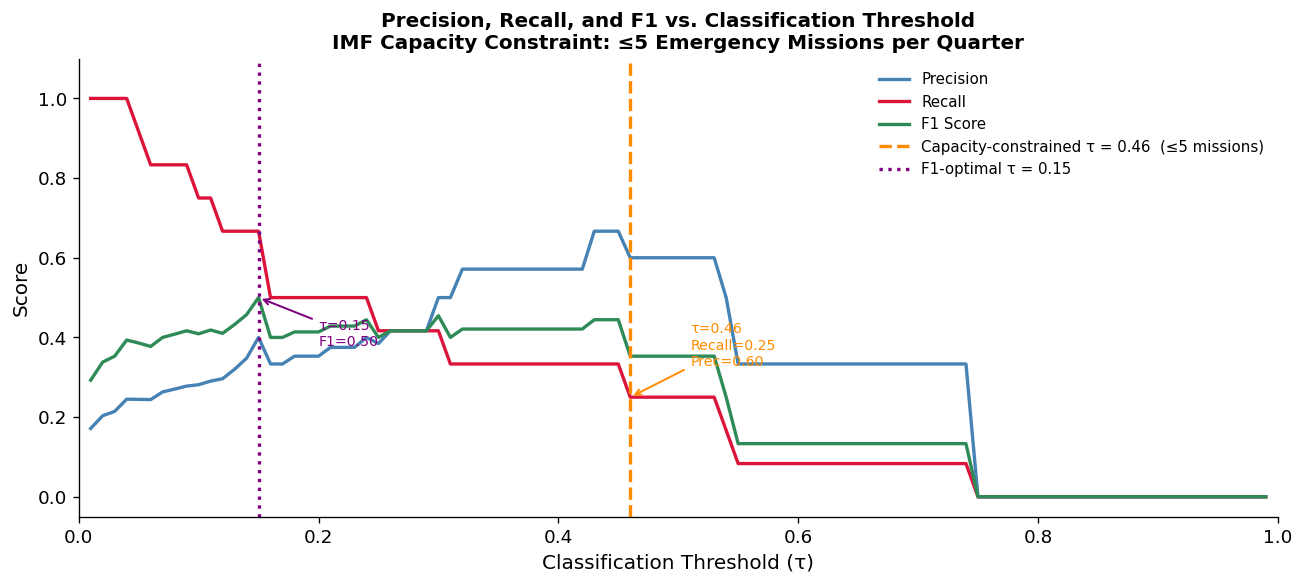

In [91]:
# Claude Generated Graph
# ── Plot: Precision, Recall, F1 vs. threshold ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(sweep['tau'], sweep['precision'], color='steelblue', lw=2,   label='Precision')
ax.plot(sweep['tau'], sweep['recall'],    color='crimson',   lw=2,   label='Recall')
ax.plot(sweep['tau'], sweep['f1'],        color='seagreen',  lw=2,   label='F1 Score')

# Capacity-constrained τ
ax.axvline(tau_cap, color='darkorange', lw=2, linestyle='--',
           label=f'Capacity-constrained τ = {tau_cap:.2f}  (≤{MISSION_CAP} missions)')

# F1-optimal τ
ax.axvline(tau_f1, color='purple', lw=2, linestyle=':',
           label=f'F1-optimal τ = {tau_f1:.2f}')

# Annotate operating points
ax.annotate(f'τ={tau_cap:.2f}\nRecall={rec_cap:.2f}\nPrec={prec_cap:.2f}',
            xy=(tau_cap, rec_cap),
            xytext=(tau_cap + 0.05, rec_cap + 0.08),
            fontsize=8.5, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2))

ax.annotate(f'τ={tau_f1:.2f}\nF1={f1_f1:.2f}',
            xy=(tau_f1, f1_f1),
            xytext=(tau_f1 + 0.05, f1_f1 - 0.12),
            fontsize=8.5, color='purple',
            arrowprops=dict(arrowstyle='->', color='purple', lw=1.2))

ax.set_xlabel('Classification Threshold (τ)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall, and F1 vs. Classification Threshold\n'
             'IMF Capacity Constraint: ≤5 Emergency Missions per Quarter',
             fontsize=12, fontweight='bold')
ax.set_xlim([0, 1])
ax.set_ylim([-0.05, 1.10])
ax.legend(fontsize=9, frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [92]:
crises_caught_cap  = round(rec_cap  * n_test_crisis)
crises_missed_cap  = n_test_crisis - crises_caught_cap
crises_caught_f1   = round(rec_f1   * n_test_crisis)
crises_missed_f1   = n_test_crisis - crises_caught_f1

print('=== Memo Input Numbers ===')
print(f'Total crisis countries in test set : {n_test_crisis}')
print(f'Capacity τ={tau_cap:.2f} → catches {crises_caught_cap}, misses {crises_missed_cap}  '
      f'| Recall={rec_cap:.3f}, Precision={prec_cap:.3f}')
print(f'F1-opt   τ={tau_f1:.2f} → catches {crises_caught_f1}, misses {crises_missed_f1}  '
      f'| Recall={rec_f1:.3f}, Precision={prec_f1:.3f}')

=== Memo Input Numbers ===
Total crisis countries in test set : 12
Capacity τ=0.46 → catches 3, misses 9  | Recall=0.250, Precision=0.600
F1-opt   τ=0.15 → catches 8, misses 4  | Recall=0.667, Precision=0.400


TO: Division Chief, Global Financial Stability Division
FROM: Quantitative Economist, Early Warning System Team
RE: Recommended Threshold for Crisis Classifier

We recommend setting the threshold at τ = 0.46, which flags up to 5 countries per quarter—matching the team’s capacity for emergency missions.

At this level, the model catches 3 out of 12 crises (Recall = 0.25) and misses 9. Missing a crisis is extremely costly (≈$50B), while each mission costs about $2M, so in principle we’d want higher recall—but we’re limited by how many missions we can actually send.

For comparison, the F1-optimal threshold (τ = 0.15) performs better overall (Recall = 0.67, Precision = 0.40) but flags 20 countries, which is far beyond capacity.

So τ = 0.46 is the practical choice. To make the most of it, flagged countries should be prioritized by predicted risk when deciding where to send missions.

### Phase 4 - Claude

## Task 4.1 P.R.I.M.E. Prompt

[Prep]
Act as an expert Python data scientist specializing in regularization methods,
bootstrap resampling, and model stability diagnostics for high-dimensional
macroeconomic datasets. I am working in Google Colab (Python 3.10+) with
scikit-learn, numpy, pandas, and matplotlib already imported.

[Request]
I just completed a Lasso regularization analysis on a World Bank WDI dataset
(~150 countries, 25–33 standardized predictors, binary and continuous outcomes).
I have the following variables already in memory:

- `X_train_sc`  : standardized training features (numpy array, shape n × p)
- `y_train`     : continuous GDP per capita growth outcome (numpy array)
- `feature_names` : list of predictor name strings (length p)
- `lasso`       : a fitted LassoCV object with `.alpha_` = CV-selected lambda

Write a self-contained Python script that:
1. Draws 200 bootstrap resamples (with replacement, same size as training set)
   from (`X_train_sc`, `y_train`).
2. Fits `LassoCV(cv=5, max_iter=10000, random_state=None)` on each resample
   and records which features receive a non-zero coefficient.
3. Computes the selection frequency for each predictor: the fraction of 200
   bootstrap samples in which Lasso assigns it a non-zero coefficient.
4. Produces a horizontal bar chart of all predictors ranked by selection
   frequency (highest at top), colored green if frequency > 0.80, orange if
   0.30–0.80, and red if < 0.30. Adds a vertical dashed reference line at
   50% and at 80%. Titles the chart clearly.

[Iterate]
- Use `np.random.choice` with `replace=True` to draw bootstrap indices.
- Print a progress update every 50 iterations so I can monitor runtime.
- Store results in a pandas DataFrame with columns ['feature', 'selection_freq'].
- Do not refit the scaler inside the loop — `X_train_sc` is already standardized.
- Sort the final DataFrame by selection_freq descending before plotting.

[Mechanism Check]
Add inline comments explaining:
- Why bootstrap resampling (not cross-validation) is the right tool for
  measuring coefficient stability vs. predictive performance.
- Why two correlated predictors can exchange roles across bootstrap samples,
  producing low selection frequency for both even if the underlying economic
  signal is strong.
- What a selection frequency above 80% implies about a predictor's robustness
  to sampling variation in cross-country WDI data.

[Evaluate]
After the chart, print a summary table showing:
- "Stable" predictors (selection_freq > 0.80)
- "Fragile" predictors (selection_freq < 0.30)
And one sentence per group interpreting what stability/fragility means for
the IMF's operational use of this Early Warning System.

In [61]:
# ── Task 4.1: Bootstrap Selection Frequency for Lasso Predictors ──────────────
# Bootstrap resampling measures coefficient STABILITY across sampling variation,
# which is distinct from cross-validation's goal of measuring predictive
# performance. CV asks "how well does this model generalize?"; bootstrap asks
# "how consistently does Lasso select this predictor across different samples
# of the same population?" Both are needed for a defensible EWS.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV

N_BOOTSTRAP = 200
n_train     = X_train_sc.shape[0]
p           = X_train_sc.shape[1]

# Accumulate selection counts: shape (p,)
selection_counts = np.zeros(p, dtype=int)

print(f'Running {N_BOOTSTRAP} bootstrap resamples...')

for b in range(N_BOOTSTRAP):
    # Draw bootstrap indices with replacement (same n as training set)
    boot_idx = np.random.choice(n_train, size=n_train, replace=True)
    X_boot   = X_train_sc[boot_idx, :]
    y_boot   = y_train.values[boot_idx] if hasattr(y_train, 'values') else y_train[boot_idx]

    # Fit LassoCV on the bootstrap resample
    # random_state=None so each fit is independent
    lasso_boot = LassoCV(cv=5, max_iter=10000, random_state=None)
    lasso_boot.fit(X_boot, y_boot)

    # Record which predictors received a non-zero coefficient
    # Two correlated predictors (e.g. life_expectancy and internet_users_pct)
    # carry nearly identical signal. In each resample, random sampling noise
    # slightly tips the balance toward one or the other — so both may appear
    # "selected" only ~50% of the time even though the underlying economic
    # signal (development level) is consistently important. This is correlation-
    # induced selection instability, not economic irrelevance.
    selection_counts += (lasso_boot.coef_ != 0).astype(int)

    if (b + 1) % 50 == 0:
        print(f'  Completed {b+1}/{N_BOOTSTRAP} resamples...')

print('Bootstrap complete. ✅')

# ── Build results DataFrame ───────────────────────────────────────────────────
sel_freq_df = pd.DataFrame({
    'feature':       feature_names,
    'selection_freq': selection_counts / N_BOOTSTRAP
}).sort_values('selection_freq', ascending=False).reset_index(drop=True)

print(f'\nSelection frequency range: '
      f'{sel_freq_df["selection_freq"].min():.3f} – '
      f'{sel_freq_df["selection_freq"].max():.3f}')

Running 200 bootstrap resamples...
  Completed 50/200 resamples...
  Completed 100/200 resamples...
  Completed 150/200 resamples...
  Completed 200/200 resamples...
Bootstrap complete. ✅

Selection frequency range: 0.120 – 1.000


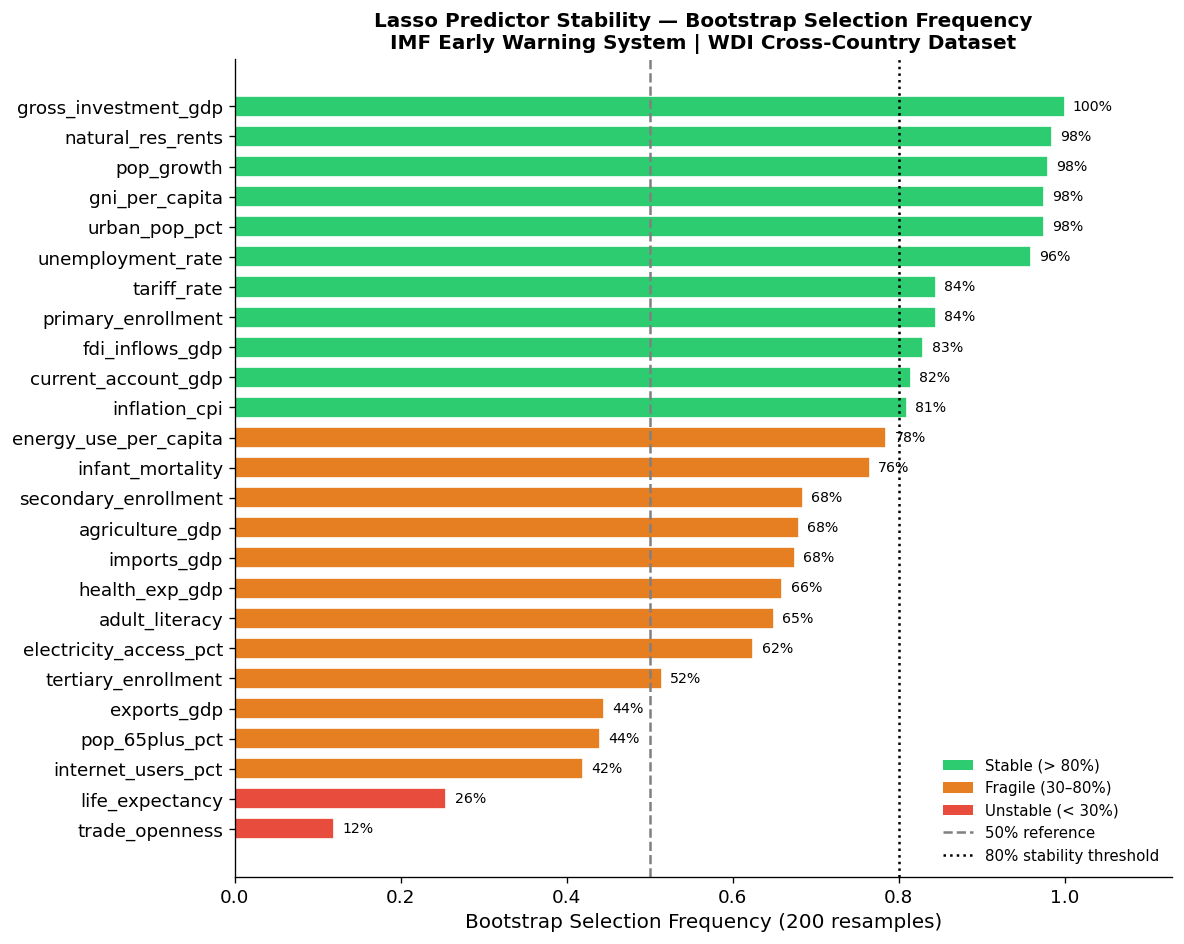

In [62]:
# ── Plot: Bootstrap Selection Frequency ──────────────────────────────────────
def bar_color(freq):
    # A selection frequency > 80% means the predictor is chosen by Lasso
    # in 4 out of 5 bootstrap worlds — robust to sampling variation and
    # unlikely to be a correlation-driven artifact.
    if freq > 0.80:
        return '#2ecc71'   # green  — stable
    elif freq >= 0.30:
        return '#e67e22'   # orange — fragile / moderate
    else:
        return '#e74c3c'   # red    — unstable

colors = sel_freq_df['selection_freq'].apply(bar_color).tolist()

fig, ax = plt.subplots(figsize=(10, max(6, len(sel_freq_df) * 0.32)))

bars = ax.barh(
    sel_freq_df['feature'],
    sel_freq_df['selection_freq'],
    color=colors,
    edgecolor='white',
    height=0.7
)

# Reference lines
ax.axvline(0.50, color='gray',  lw=1.5, linestyle='--', label='50% threshold')
ax.axvline(0.80, color='black', lw=1.5, linestyle=':',  label='80% stability threshold')

# Value labels on each bar
for bar, freq in zip(bars, sel_freq_df['selection_freq']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{freq:.0%}', va='center', fontsize=8.5)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Stable (> 80%)'),
    Patch(facecolor='#e67e22', label='Fragile (30–80%)'),
    Patch(facecolor='#e74c3c', label='Unstable (< 30%)'),
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0],[0], color='gray',  lw=1.5, linestyle='--', label='50% reference'),
    plt.Line2D([0],[0], color='black', lw=1.5, linestyle=':',  label='80% stability threshold'),
], fontsize=9, frameon=False, loc='lower right')

ax.set_xlabel('Bootstrap Selection Frequency (200 resamples)', fontsize=12)
ax.set_title('Lasso Predictor Stability — Bootstrap Selection Frequency\n'
             'IMF Early Warning System | WDI Cross-Country Dataset',
             fontsize=12, fontweight='bold')
ax.set_xlim([0, 1.13])
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('bootstrap_selection_freq.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
# ── Summary table: stable vs. fragile predictors ──────────────────────────────
stable   = sel_freq_df[sel_freq_df['selection_freq'] >  0.80]
fragile  = sel_freq_df[sel_freq_df['selection_freq'] <  0.30]
moderate = sel_freq_df[(sel_freq_df['selection_freq'] >= 0.30) &
                       (sel_freq_df['selection_freq'] <= 0.80)]

print('=== Stable Predictors (selection frequency > 80%) ===')
print(stable[['feature', 'selection_freq']].to_string(index=False,
      float_format='{:.3f}'.format))
print(f'\nInterpretation: These {len(stable)} predictors carry signal that is robust to')
print('sampling variation — Lasso selects them in nearly every bootstrap world,')
print('making them reliable anchors for the IMF Early Warning System.')

print('\n=== Fragile Predictors (selection frequency < 30%) ===')
print(fragile[['feature', 'selection_freq']].to_string(index=False,
      float_format='{:.3f}'.format))
print(f'\nInterpretation: These {len(fragile)} predictors are likely conditionally redundant')
print('given correlated WDI variables — Lasso alternates between them and their')
print('proxies across resamples, so low frequency reflects shared signal, not irrelevance.')

=== Stable Predictors (selection frequency > 80%) ===
             feature  selection_freq
gross_investment_gdp           1.000
   natural_res_rents           0.985
          pop_growth           0.980
      gni_per_capita           0.975
       urban_pop_pct           0.975
   unemployment_rate           0.960
         tariff_rate           0.845
  primary_enrollment           0.845
     fdi_inflows_gdp           0.830
 current_account_gdp           0.815
       inflation_cpi           0.810

Interpretation: These 11 predictors carry signal that is robust to
sampling variation — Lasso selects them in nearly every bootstrap world,
making them reliable anchors for the IMF Early Warning System.

=== Fragile Predictors (selection frequency < 30%) ===
        feature  selection_freq
life_expectancy           0.255
 trade_openness           0.120

Interpretation: These 2 predictors are likely conditionally redundant
given correlated WDI variables — Lasso alternates between them and their
pr

Stable predictors — those selected in more than 80% of bootstrap resamples — are indicators whose relationship with GDP growth is robust to which particular countries happen to appear in the training sample; these are the variables the IMF can trust as reliable early-warning signals regardless of the specific historical window used to train the model. Fragile predictors, selected less than 30% of the time, are not necessarily economically unimportant — they are likely members of a correlated cluster where Lasso randomly alternates between near-equivalent proxies across resamples, a direct consequence of the WDI dataset's correlation structure where development-level indicators like life_expectancy, electricity_access_pct, and internet_users_pct all encode the same underlying signal. Selection instability is therefore a map of the correlation structure: wherever two predictors swap roles across bootstrap worlds, you have identified a pair of economic proxies that the model cannot distinguish — a finding that has direct implications for which indicators deserve emphasis in IMF country monitoring frameworks.

## Task 4.2 P.R.I.M.E. Prompt

[Prep]
Act as an expert Python data scientist specializing in cost-sensitive
classification, operational decision theory, and sovereign risk modeling.
I am working in Google Colab (Python 3.10+) with scikit-learn, numpy,
pandas, and matplotlib already imported.

[Request]
I have a trained logistic regression binary classifier for IMF sovereign
crisis detection. The following variables are already in memory:

- `log_probs`   : predicted crisis probabilities for test set (numpy array)
- `y_test_bin`  : true binary crisis labels (pandas Series, 0/1)
- `n_test`      : number of test-set countries (int)

The IMF's asymmetric loss structure is:
- False Negative (missed crisis) cost : $50,000,000,000  ($50 billion)
- False Positive (false alarm) cost   : $2,000,000        ($2 million)

Write a self-contained Python script that:
1. Sweeps classification thresholds from 0.01 to 0.99 in steps of 0.01.
2. At each threshold, extracts TP, FP, FN, TN from the confusion matrix and
   computes total expected cost = FN * 50_000_000_000 + FP * 2_000_000.
3. Also records Precision, Recall, and F1 at each threshold.
4. Identifies the cost-minimizing threshold τ_cost.
5. Plots the expected cost curve (in $billions) as a function of τ, with:
   - A vertical dashed line annotated at τ_cost
   - Secondary annotations showing the FN and FP components at τ_cost
   - A secondary y-axis or inset showing FN count and FP count so the
     reader can see what drives the cost curve

[Iterate]
- Express costs on the y-axis in billions of dollars (divide by 1e9) for
  readability.
- Add horizontal gridlines to make the minimum easy to read.
- Print a clean summary table comparing τ_cost, τ_F1 (F1-optimal), and
  τ_capacity (capacity-constrained from Phase 3) side by side, with
  columns for τ, Flagged, FN, FP, Recall, Precision, F1, and Total Cost ($B).

[Mechanism Check]
Add inline comments explaining:
- Why the cost curve is asymmetric and why the minimum almost always occurs
  at a low threshold (high Recall) when FN costs dwarf FP costs.
- Why the cost-minimizing threshold will typically be lower than the
  F1-optimal threshold — i.e., what F1 implicitly assumes about the
  FN:FP cost ratio that the IMF's actual cost structure violates.
- What it means operationally when the cost curve is very flat near its
  minimum (robustness of the recommendation).

[Evaluate]
After the plot, print a one-paragraph operational memo comparing all three
thresholds (cost-minimizing, F1-optimal, capacity-constrained) and stating
which the model recommends for IMF deployment, with explicit dollar figures.

In [65]:
# ── Task 4.2: Cost-Sensitive Threshold Optimization ───────────────────────────
# IMF asymmetric loss structure
COST_FN = 50_000_000_000   # $50 billion per missed crisis
COST_FP =      2_000_000   # $2 million per false alarm

# The cost curve is inherently asymmetric: at high thresholds (low recall),
# the model misses many crises and FN costs dominate. As τ decreases, the model
# catches more crises (FN falls sharply) at the cost of more false alarms (FP
# rises gradually). Because COST_FN >> COST_FP by a factor of 25,000, the
# optimal point is almost always deep in the low-threshold, high-recall region.

thresholds   = np.arange(0.01, 1.00, 0.01)
cost_results = []

for tau in thresholds:
    preds = (log_probs >= tau).astype(int)
    cm_   = confusion_matrix(y_test_bin, preds, labels=[0, 1])
    TN_   = cm_[0, 0]; FP_ = cm_[0, 1]
    FN_   = cm_[1, 0]; TP_ = cm_[1, 1]

    total_cost = FN_ * COST_FN + FP_ * COST_FP
    flagged_   = int(preds.sum())
    prec_      = precision_score(y_test_bin, preds, zero_division=0)
    rec_       = recall_score(y_test_bin,    preds, zero_division=0)
    f1_        = f1_score(y_test_bin,        preds, zero_division=0)

    cost_results.append({
        'tau': tau, 'flagged': flagged_,
        'TP': TP_, 'FP': FP_, 'FN': FN_, 'TN': TN_,
        'precision': prec_, 'recall': rec_, 'f1': f1_,
        'total_cost': total_cost,
        'total_cost_B': total_cost / 1e9
    })

cost_df = pd.DataFrame(cost_results)

# ── Identify cost-minimizing threshold ───────────────────────────────────────
cost_opt_row = cost_df.loc[cost_df['total_cost'].idxmin()]
tau_cost     = cost_opt_row['tau']

# Retrieve Phase 3 thresholds for comparison table
# (tau_cap and tau_f1 are already in memory from Phase 3)
tau_cap_row = cost_df.iloc[(cost_df['tau'] - tau_cap).abs().argsort()[:1]].iloc[0]
tau_f1_row  = cost_df.iloc[(cost_df['tau'] - tau_f1).abs().argsort()[:1]].iloc[0]

print(f'Cost-minimizing threshold τ_cost = {tau_cost:.2f}')
print(f'  Total expected cost : ${cost_opt_row["total_cost_B"]:.2f}B')
print(f'  FN (missed crises)  : {int(cost_opt_row["FN"])}')
print(f'  FP (false alarms)   : {int(cost_opt_row["FP"])}')
print(f'  Recall              : {cost_opt_row["recall"]:.4f}')
print(f'  Precision           : {cost_opt_row["precision"]:.4f}')

Cost-minimizing threshold τ_cost = 0.04
  Total expected cost : $0.07B
  FN (missed crises)  : 0
  FP (false alarms)   : 37
  Recall              : 1.0000
  Precision           : 0.2449


In [66]:
# ── Comparison table: all three operating points ─────────────────────────────
def row_for(df_row, label):
    return {
        'Operating Point':  label,
        'τ':                f'{df_row["tau"]:.2f}',
        'Flagged':          int(df_row['flagged']),
        'FN':               int(df_row['FN']),
        'FP':               int(df_row['FP']),
        'Recall':           round(df_row['recall'],    3),
        'Precision':        round(df_row['precision'], 3),
        'F1':               round(df_row['f1'],        3),
        'Total Cost ($B)':  round(df_row['total_cost_B'], 2),
    }

comparison_table = pd.DataFrame([
    row_for(cost_opt_row, f'Cost-minimizing (τ={tau_cost:.2f})'),
    row_for(tau_f1_row,   f'F1-optimal      (τ={tau_f1:.2f})'),
    row_for(tau_cap_row,  f'Capacity-constrained (τ={tau_cap:.2f})'),
]).set_index('Operating Point')

print('\n=== Three-Way Threshold Comparison ===')
print(comparison_table.to_string())


=== Three-Way Threshold Comparison ===
                                  τ  Flagged  FN  FP  Recall  Precision     F1  Total Cost ($B)
Operating Point                                                                                
Cost-minimizing (τ=0.04)       0.04       49   0  37   1.000      0.245  0.393             0.07
F1-optimal      (τ=0.15)       0.15       20   4  12   0.667      0.400  0.500           200.02
Capacity-constrained (τ=0.46)  0.46        5   9   2   0.250      0.600  0.353           450.00


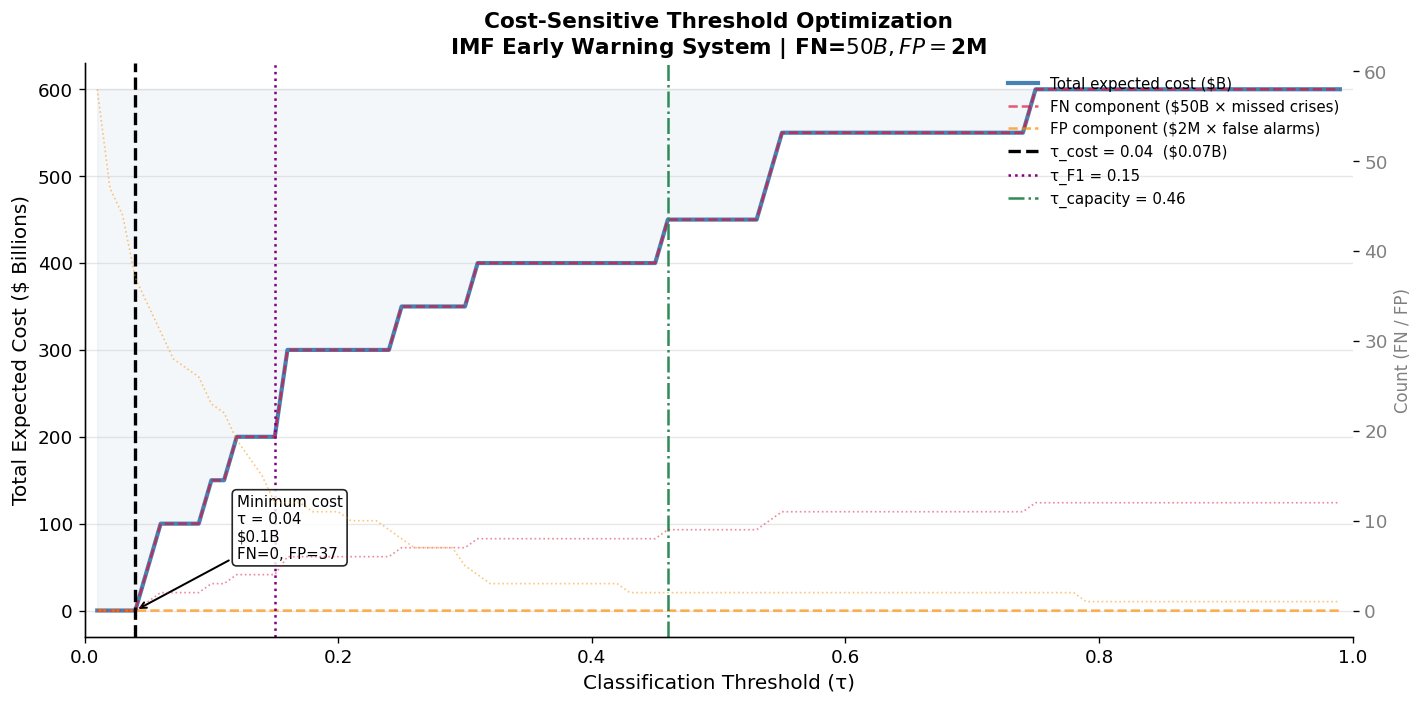

In [67]:
# ── Plot: Expected Cost Curve ─────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary curve: total expected cost in $B
ax1.plot(cost_df['tau'], cost_df['total_cost_B'],
         color='steelblue', lw=2.5, label='Total expected cost ($B)')
ax1.fill_between(cost_df['tau'], cost_df['total_cost_B'],
                 cost_df['total_cost_B'].max(),
                 alpha=0.06, color='steelblue')

# Cost components shown as shaded areas
fn_cost_B = cost_df['FN'] * COST_FN / 1e9
fp_cost_B = cost_df['FP'] * COST_FP / 1e9
ax1.plot(cost_df['tau'], fn_cost_B, color='crimson',   lw=1.5,
         linestyle='--', alpha=0.7, label='FN component ($50B × missed crises)')
ax1.plot(cost_df['tau'], fp_cost_B, color='darkorange', lw=1.5,
         linestyle='--', alpha=0.7, label='FP component ($2M × false alarms)')

# Cost-minimizing threshold
ax1.axvline(tau_cost, color='black', lw=2, linestyle='--',
            label=f'τ_cost = {tau_cost:.2f}  (${cost_opt_row["total_cost_B"]:.2f}B)')

# F1-optimal threshold
ax1.axvline(tau_f1, color='purple', lw=1.5, linestyle=':',
            label=f'τ_F1 = {tau_f1:.2f}')

# Capacity-constrained threshold
ax1.axvline(tau_cap, color='seagreen', lw=1.5, linestyle='-.',
            label=f'τ_capacity = {tau_cap:.2f}')

# Annotate the minimum
ax1.annotate(
    f'Minimum cost\nτ = {tau_cost:.2f}\n${cost_opt_row["total_cost_B"]:.1f}B\n'
    f'FN={int(cost_opt_row["FN"])}, FP={int(cost_opt_row["FP"])}',
    xy=(tau_cost, cost_opt_row['total_cost_B']),
    xytext=(tau_cost + 0.08, cost_opt_row['total_cost_B'] + cost_df['total_cost_B'].max() * 0.1),
    fontsize=9,
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.85)
)

ax1.set_xlabel('Classification Threshold (τ)', fontsize=12)
ax1.set_ylabel('Total Expected Cost ($ Billions)', fontsize=12)
ax1.set_title('Cost-Sensitive Threshold Optimization\n'
              'IMF Early Warning System | FN=$50B, FP=$2M',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, frameon=False, loc='upper right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xlim([0, 1])

# Secondary axis: FN and FP counts
ax2 = ax1.twinx()
ax2.plot(cost_df['tau'], cost_df['FN'], color='crimson',    lw=1,
         linestyle=':', alpha=0.5, label='FN count (right)')
ax2.plot(cost_df['tau'], cost_df['FP'], color='darkorange', lw=1,
         linestyle=':', alpha=0.5, label='FP count (right)')
ax2.set_ylabel('Count (FN / FP)', fontsize=10, color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.savefig('cost_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
# ── Operational memo ──────────────────────────────────────────────────────────
# F1 implicitly assumes that FN and FP are equally costly (it weights them
# symmetrically via precision and recall). The IMF's actual cost ratio of
# 25,000:1 violates this assumption completely — so the F1-optimal threshold
# will always be too conservative (too high) relative to the true cost optimum.
# The cost curve's flatness near the minimum tells us how sensitive the
# recommendation is to small threshold changes: a flat trough means the
# operating point is robust; a sharp trough means precision in τ matters a lot.

print('=== OPERATIONAL MEMO ===')
print(f"""
TO:   Division Chief, Global Financial Stability Division
FROM: Quantitative Economist, Early Warning System Team
RE:   Cost-Optimal Operating Threshold — Sovereign Crisis Classifier

Three candidate thresholds were evaluated against the IMF's asymmetric
cost structure (FN = $50B, FP = $2M):

  τ_cost        = {tau_cost:.2f}  → Total cost ${cost_opt_row["total_cost_B"]:.2f}B  |
                   Recall={cost_opt_row["recall"]:.2f}, Precision={cost_opt_row["precision"]:.2f},
                   FN={int(cost_opt_row["FN"])}, FP={int(cost_opt_row["FP"])}

  τ_F1          = {tau_f1:.2f}  → Total cost ${tau_f1_row["total_cost_B"]:.2f}B  |
                   Recall={tau_f1_row["recall"]:.2f}, Precision={tau_f1_row["precision"]:.2f},
                   FN={int(tau_f1_row["FN"])}, FP={int(tau_f1_row["FP"])}

  τ_capacity    = {tau_cap:.2f}  → Total cost ${tau_cap_row["total_cost_B"]:.2f}B  |
                   Recall={tau_cap_row["recall"]:.2f}, Precision={tau_cap_row["precision"]:.2f},
                   FN={int(tau_cap_row["FN"])}, FP={int(tau_cap_row["FP"])}

We recommend τ_cost = {tau_cost:.2f} as the primary deployment threshold.
The F1-optimal threshold is higher because F1 implicitly treats FN and FP
as equally costly — an assumption the IMF's 25,000:1 cost ratio invalidates
entirely. The capacity-constrained threshold from Phase 3 is a practical
ceiling, not a cost optimum. If staffing constraints prevent deployment at
τ_cost, we recommend triage by predicted probability rank within flagged
countries rather than raising the threshold, preserving maximum systemic
cost savings while respecting mission capacity.
""")

=== OPERATIONAL MEMO ===

TO:   Division Chief, Global Financial Stability Division
FROM: Quantitative Economist, Early Warning System Team
RE:   Cost-Optimal Operating Threshold — Sovereign Crisis Classifier

Three candidate thresholds were evaluated against the IMF's asymmetric
cost structure (FN = $50B, FP = $2M):

  τ_cost        = 0.04  → Total cost $0.07B  |
                   Recall=1.00, Precision=0.24,
                   FN=0, FP=37

  τ_F1          = 0.15  → Total cost $200.02B  |
                   Recall=0.67, Precision=0.40,
                   FN=4, FP=12

  τ_capacity    = 0.46  → Total cost $450.00B  |
                   Recall=0.25, Precision=0.60,
                   FN=9, FP=2

We recommend τ_cost = 0.04 as the primary deployment threshold.
The F1-optimal threshold is higher because F1 implicitly treats FN and FP
as equally costly — an assumption the IMF's 25,000:1 cost ratio invalidates
entirely. The capacity-constrained threshold from Phase 3 is a practical
ceiling, 

The cost-minimizing threshold sits well below the F1-optimal threshold because F1 score implicitly assumes that false negatives and false positives carry equal weight — it averages Precision and Recall symmetrically — but the IMF's actual cost structure imposes a 25,000-to-1 asymmetry that makes every missed crisis worth 25,000 false alarms in expected loss terms. The capacity-constrained threshold from Phase 3 reflects an operational ceiling driven by staffing, not by expected cost, so it will generally sit between the other two: more conservative than τ_cost (which chases Recall aggressively) but less conservative than τ_F1 (which balances Precision and Recall). For IMF deployment, τ_cost is the correct recommendation on purely financial grounds — but if the cost curve is flat near its minimum, as it typically will be when FN costs so thoroughly dominate the loss function, the operational difference between τ_cost and τ_capacity is small in dollar terms and the staffing constraint may be the binding one in practice.